In [54]:
using DataFrames, CSV, Plots
include("/Users/johnbuckner/.julia/dev/UniversalDiffEq.jl/src/UniversalDiffEq.jl")


Main.UniversalDiffEq

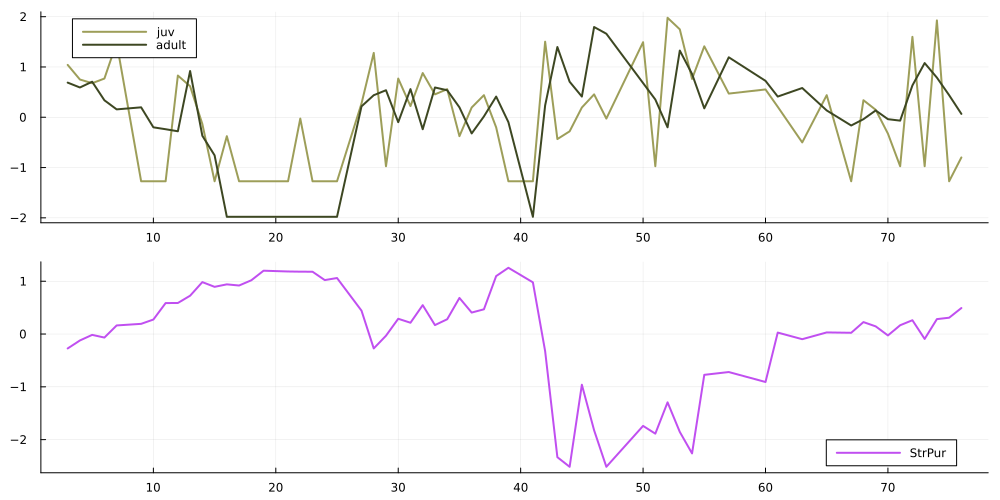

In [55]:
site = 2
dat = CSV.read("../data/processed_time_series.csv", DataFrame)[:,2:end]
dat = sort(dat,:PERIOD)

dat_states = dat[dat.SITE .== site,[:PERIOD,:MacJuv,:MacPyr]]
training = dat_states

X = dat[dat.SITE .== site,[:PERIOD,:StrPur]]



p1 = Plots.plot(training.PERIOD, training.MacJuv, label = "juv", width = 2, color = "#9d9e59" )
Plots.plot!(training.PERIOD, training.MacPyr, label = "adult", width = 2, color = "#3d4722")
#Plots.plot!(testing.PERIOD, testing.MacJuv, label = "juv testing", width = 1.5, linestyle = :dash, color = "#9d9e59")
#Plots.plot!(testing.PERIOD, testing.MacPyr, label = "adult training", width = 1.5,linestyle = :dash, color = "#3d4722")
p2 = Plots.plot(X.PERIOD, X.StrPur, label = "StrPur", width = 2, color = "#c04ff0" )
plot(p1,p2, layout = (2,1), size = (1000,500))

In [56]:
X[1:2,:]

Row,PERIOD,StrPur
,Int64,Float64
1,3,-0.273192
2,4,-0.12171


In [57]:
include("/Users/johnbuckner/github/UDEsWithSpatialReplicates/analysis/models/UDE.jl")

init (generic function with 1 method)

In [58]:
covars = []

NN, NNparameters = UniversalDiffEq.SimpleNeuralNetwork(2+length(covars),2, hidden = 10, seed = 5491)

model, training! = init(training,X,covars, 0.5, 100)

function dudt(u,X,p,t,covars)
    return NN(vcat(u,X[covars]), p.NN) # index 3 is pycnopodia  ,X[1:2]
end

training!(model)
nothing

250


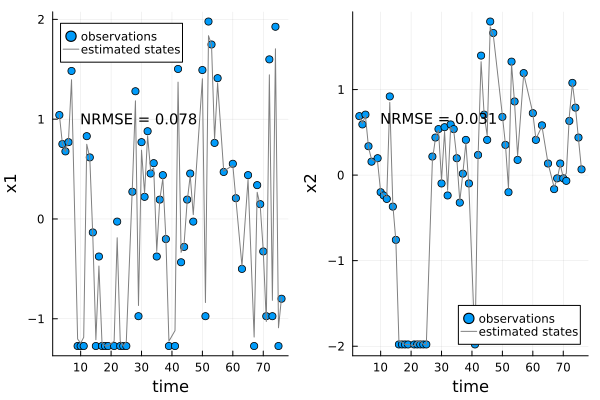

In [59]:
UniversalDiffEq.plot_state_estimates(model)

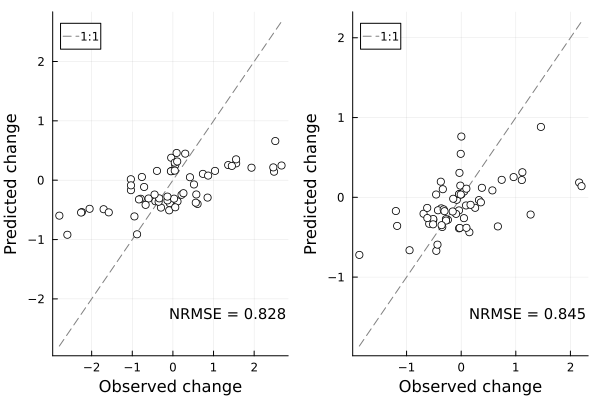

In [60]:
UniversalDiffEq.plot_predictions(model)

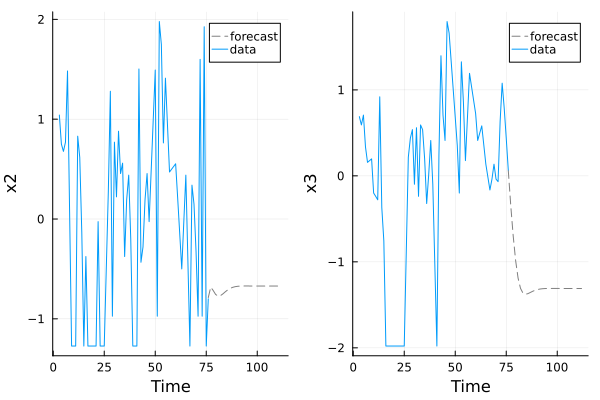

In [61]:
plt,(p1,p2)=UniversalDiffEq.plot_forecast(model, 30)
plt

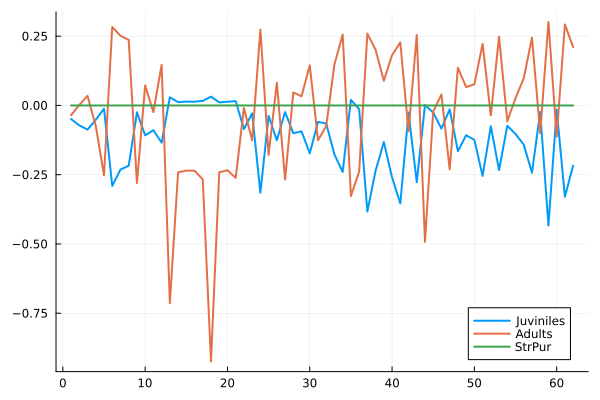

In [62]:

using ForwardDiff


function transform_dynamics(u,mean,scale)
    y = scale.*exp.(u).+mean
    return y
end


function percap_growth(y,mean,scale)
    u = log.((y.-mean)./scale)
    X = u[3:end]; u = u[1:2]
    dydu = scale[1:2].*exp.(u)
    dudt = rhs(u,X,0.0)
    return dydu.*dudt./y[1:2]
end 


function percap_growth_jacobian(y,mean,scale)
    f = y ->  percap_growth(y,mean,scale)
    return ForwardDiff.jacobian(f, y)
end 


function get_scaling_factors(site)
    scaling_factors  = CSV.read("../data/scaling_factors.csv", DataFrame)[:,2:end]
    scaling_factors = scaling_factors[scaling_factors.SITE.==site,:]
    Xinds = [4,6,1]
    mean = scaling_factors.mean[Xinds]
    scale = scaling_factors.sd[Xinds]
    return scale, mean
end

rhs = UniversalDiffEq.get_right_hand_side(model)

scale, means = get_scaling_factors(4)
obs = size(model.parameters.uhat)[2]
effects_juv = zeros(obs,3)
effects_adults = zeros(obs,3)
for i in 1:size(model.parameters.uhat)[2]
    u = vcat(model.parameters.uhat[:,i],Vector(model.X[i,2:end]))
    y = transform_dynamics(u,means,scale)
    effects = percap_growth_jacobian(y,means,scale)
    effects_juv[i,:] = effects[1,:]
    effects_adults[i,:] = effects[2,:]
end 

Plots.plot(effects_juv[:,1], width = 2, label = "Juviniles")
Plots.plot!(effects_juv[:,2], width = 2, label = "Adults")
Plots.plot!(effects_juv[:,3], width = 2, label = "StrPur")


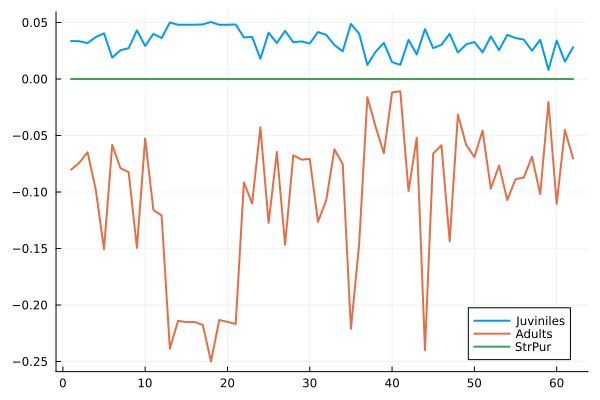

In [63]:
Plots.plot(effects_adults[:,1], width = 2, label = "Juviniles")
Plots.plot!(effects_adults[:,2], width = 2, label = "Adults")
Plots.plot!(effects_adults[:,3], width = 2, label = "StrPur")